In [2]:
# Instalacao das dependencias — execute esta celula primeiro!
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn --quiet
print("Instalacao concluida! Execute as proximas celulas normalmente.")

Instalacao concluida! Execute as proximas celulas normalmente.


# Tech Challenge Fase 1 — NPS Preditivo
## Case: Previsão de Satisfação de Clientes em E-commerce

> **Objetivo**: Transformar dados operacionais em insights acionáveis e construir um modelo
> preditivo capaz de antecipar o NPS do cliente antes da pesquisa ser aplicada.


## ⚙️ Setup — Importações e Configurações

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
PALETTE = {'Detrator': '#E74C3C', 'Neutro': '#F39C12', 'Promotor': '#27AE60'}

print('Setup concluido!')

Setup concluido!


---
# PARTE 1 — Entendimento do Negócio
---

## 1.1 Qual problema de negócio está sendo resolvido?

O problema central é a **incapacidade de agir preventivamente sobre a insatisfação do cliente**.
O NPS é coletado apenas **após** o encerramento da jornada de compra, o que impede ações preventivas.
A empresa não consegue identificar, em tempo real, quais clientes estão prestes a ter uma experiência
ruim para intervir antes que isso aconteça.

---

## 1.2 Por que o NPS é importante para um e-commerce?

O NPS (Net Promoter Score) mede a **lealdade do cliente**.

| Faixa | Categoria | Comportamento |
|---|---|---|
| 0–6  | **Detrator**  | Fala mal da marca, eleva churn, não recompra |
| 7–8  | **Neutro**    | Satisfeito, mas não fiel |
| 9–10 | **Promotor**  | Recomenda ativamente, gera crescimento orgânico |

**Impacto na Recompra:** Correlação de +0,57 entre `repeat_purchase_30d` e `nps_score`.
Promotores recompram; detratores não voltam. Um cliente retido custa 5–7x menos que adquirir um novo.

**Impacto no Boca a Boca:** Um detrator conta a experiência negativa para 9–15 pessoas.
Em e-commerce, isso se amplifica via reviews e redes sociais.

**Impacto no Market Share:** Benchmark do setor: NPS médio de 30–50 pts (varejo digital).
Empresas abaixo desse patamar perdem share gradualmente.

---

## 1.3 Quais áreas se beneficiariam dos insights?

| Área | Como se beneficia |
|---|---|
| **Logística**       | Identificar rotas/regiões com maior atraso e impacto no NPS |
| **Atendimento**     | Priorizar contato proativo com clientes de alto risco |
| **Produto**         | Entender quais categorias geram mais reclamações |
| **Pricing**         | Avaliar se frete elevado afeta desproporcionalmente o NPS |
| **CRM / Marketing** | Segmentar campanhas de retenção por risco de detração |
| **Estratégia**      | Definir OKRs baseadas nos reais drivers de satisfação |

---

## 1.4 Indicadores de mercado complementares

- **Benchmark NPS varejo digital:** 30–50 pts (Bain & Co. / Satmetrix)
- **SLA logístico:** % entregas no prazo (meta ≥ 95%)
- **FCR — First Contact Resolution:** % casos resolvidos no 1º contato
- **Churn Rate por coorte:** cruzar NPS com abandono real em 60–90 dias
- **CSAT pós-atendimento:** avaliação pontual de cada interação com o SAC


---
# PARTE 2 — Definição da Target
---

## 2.1 Variável target escolhida: `nps_score`

A variável **`nps_score`** (escala contínua de 0 a 10) representa a satisfação global do cliente.

**Por que foi escolhida?**
- Captura a **percepção global** do cliente sobre toda a jornada
- Padronizada globalmente — permite benchmarking
- Permite regressão (nota contínua) ou classificação (promotor/neutro/detrator)
- Diretamente ligada a comportamentos futuros: recompra, churn, indicação

**Momento de coleta:** após o encerramento da jornada de compra (pós-entrega).
Os dados operacionais são coletados **antes** — sem data leakage temporal.

## 2.2 Riscos no uso inadequado

| Risco | Descrição |
|---|---|
| **Data Leakage** | `csat_internal_score` e `repeat_purchase_30d` excluídas do modelo |
| **Viés de resposta** | Clientes com experiências extremas respondem mais |
| **Confusão causal** | Correlação ≠ causalidade |
| **Desbalanceamento** | 74% detratores — usar AUC-ROC, F1, `class_weight='balanced'` |


---
# PARTE 3 — Análise Exploratória dos Dados (EDA)
---

In [20]:
# Carregamento e categorização
df = pd.read_csv('desafio_nps_fase_1.csv')

df['nps_category'] = pd.cut(
    df['nps_score'],
    bins=[-0.1, 6, 8, 10],
    labels=['Detrator', 'Neutro', 'Promotor']
)

print(f'Shape: {df.shape}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
print(f'\nDistribuicao NPS:')
print(df['nps_category'].value_counts())
df.head(3)

Shape: (2500, 20)
Valores nulos: 0

Distribuicao NPS:
nps_category
Detrator    1851
Neutro       448
Promotor     201
Name: count, dtype: int64


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_category
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Neutro
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detrator


In [21]:
# Estatísticas descritivas
df.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


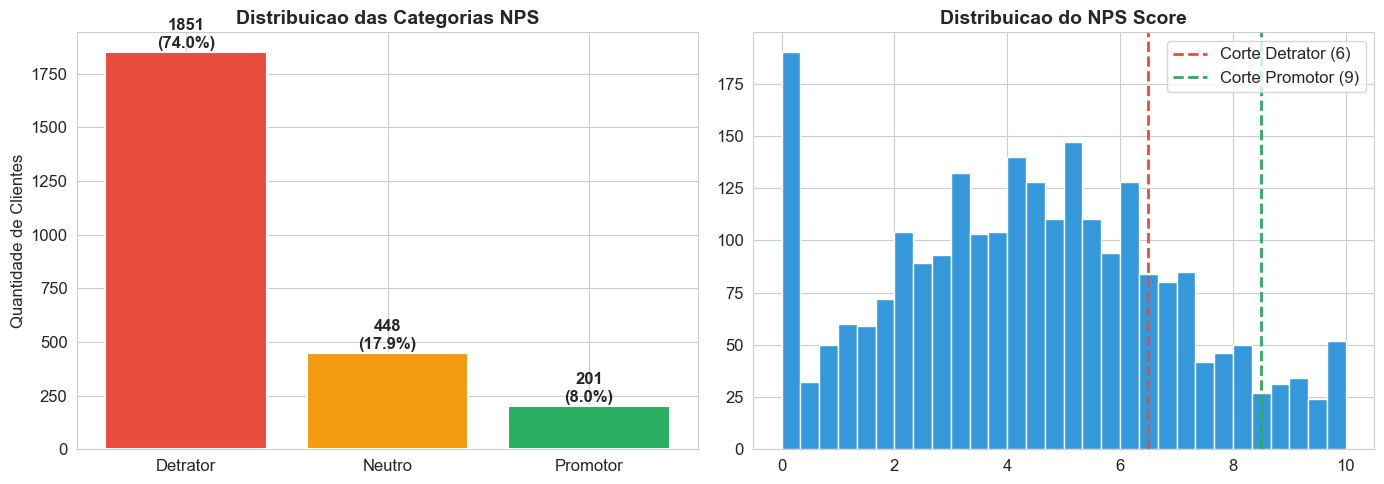

ATENCAO: 74.0% dos clientes sao DETRATORES!


In [6]:
# Fig 1 - Distribuição NPS
cat_counts = df['nps_category'].value_counts()
cat_pct = df['nps_category'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [PALETTE[c] for c in cat_counts.index]
axes[0].bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (v, p) in enumerate(zip(cat_counts.values, cat_pct.values)):
    axes[0].text(i, v + 20, f'{v}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribuicao das Categorias NPS', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade de Clientes')
axes[1].hist(df['nps_score'], bins=30, color='#3498DB', edgecolor='white')
axes[1].axvline(6.5, color='#E74C3C', linestyle='--', linewidth=2, label='Corte Detrator (6)')
axes[1].axvline(8.5, color='#27AE60', linestyle='--', linewidth=2, label='Corte Promotor (9)')
axes[1].set_title('Distribuicao do NPS Score', fontsize=14, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f'ATENCAO: {cat_pct["Detrator"]:.1f}% dos clientes sao DETRATORES!')

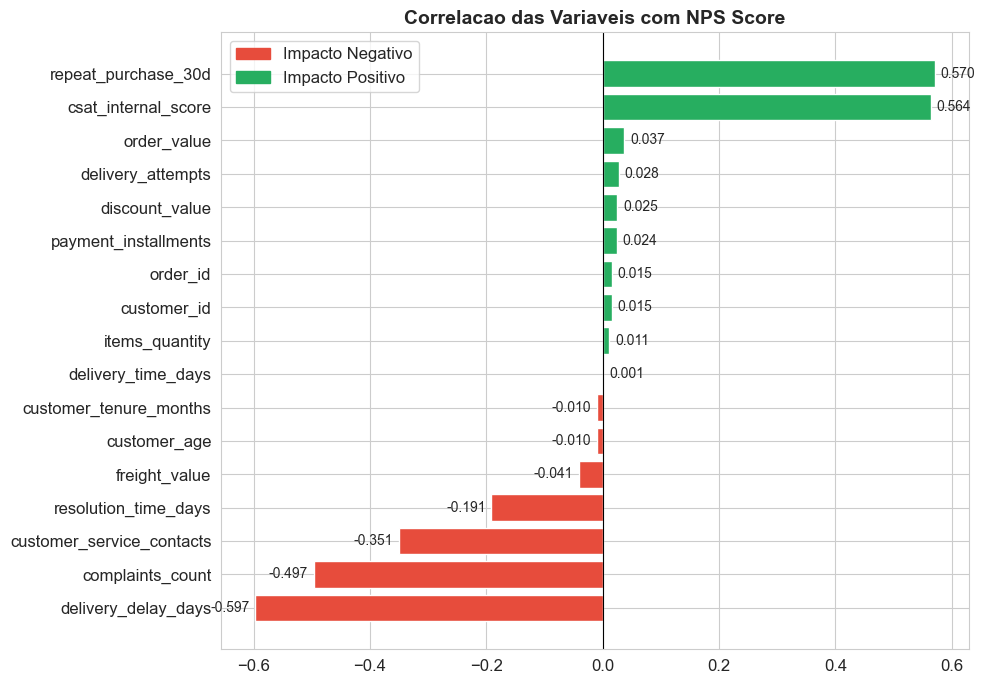

Top 3 fatores NEGATIVOS: ['delivery_delay_days', 'complaints_count', 'customer_service_contacts']


In [7]:
# Fig 2 - Correlações com NPS
corr = df.select_dtypes(include='number').corr()['nps_score'].drop('nps_score').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_corr = ['#E74C3C' if v < 0 else '#27AE60' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
ax.set_title('Correlacao das Variaveis com NPS Score', fontsize=14, fontweight='bold')
red_patch = mpatches.Patch(color='#E74C3C', label='Impacto Negativo')
green_patch = mpatches.Patch(color='#27AE60', label='Impacto Positivo')
ax.legend(handles=[red_patch, green_patch])
plt.tight_layout()
plt.show()
print('Top 3 fatores NEGATIVOS:', corr.head(3).index.tolist())

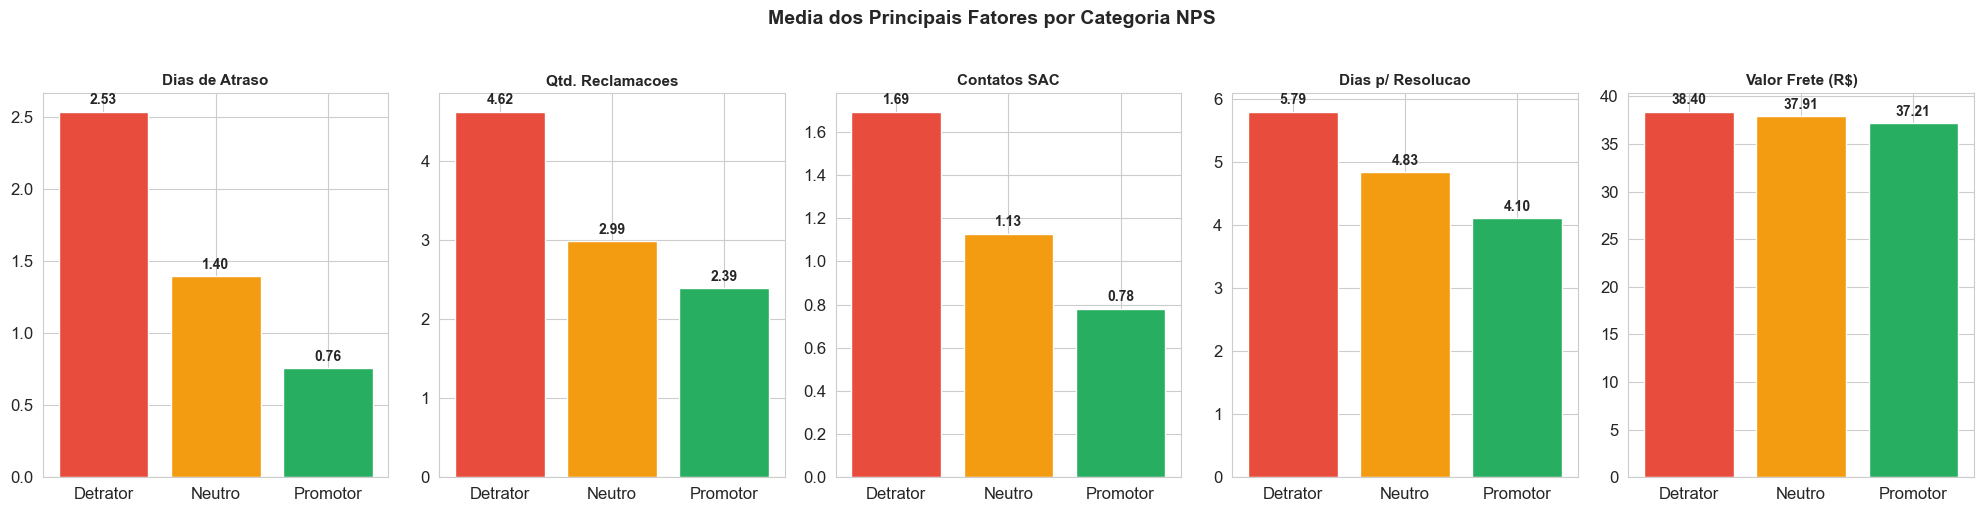

In [8]:
# Fig 3 - Médias por categoria NPS
key_vars = ['delivery_delay_days', 'complaints_count',
            'customer_service_contacts', 'resolution_time_days', 'freight_value']
labels_pt = {
    'delivery_delay_days': 'Dias de Atraso',
    'complaints_count': 'Qtd. Reclamacoes',
    'customer_service_contacts': 'Contatos SAC',
    'resolution_time_days': 'Dias p/ Resolucao',
    'freight_value': 'Valor Frete (R$)'
}
fig, axes = plt.subplots(1, len(key_vars), figsize=(20, 5))
for i, var in enumerate(key_vars):
    means = df.groupby('nps_category', observed=True)[var].mean()
    c = [PALETTE[cat] for cat in means.index]
    axes[i].bar(means.index, means.values, color=c, edgecolor='white')
    for j, v in enumerate(means.values):
        axes[i].text(j, v + means.max() * 0.02, f'{v:.2f}', ha='center', fontweight='bold', fontsize=10)
    axes[i].set_title(labels_pt[var], fontsize=11, fontweight='bold')
plt.suptitle('Media dos Principais Fatores por Categoria NPS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

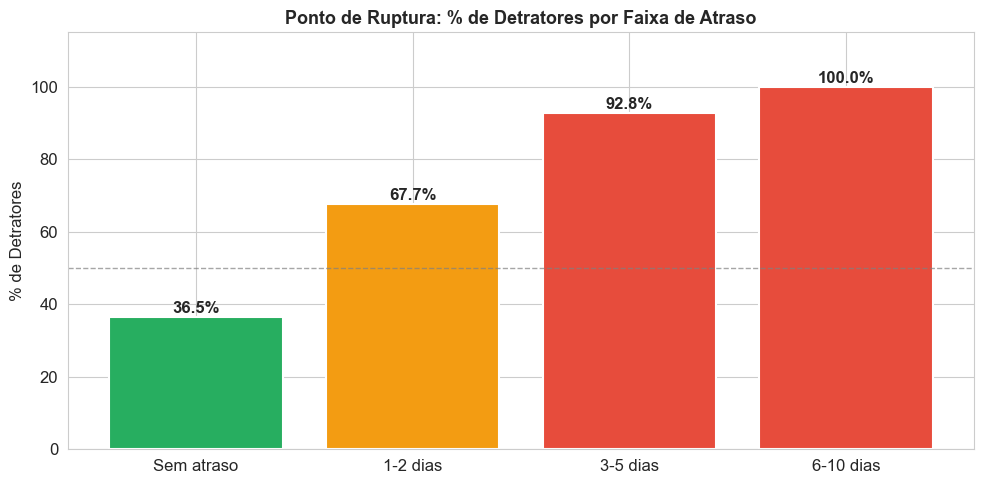

     Faixa        Pct
Sem atraso  36.462094
  1-2 dias  67.724029
  3-5 dias  92.755214
 6-10 dias 100.000000
A partir de 3 dias de atraso: 93%+ dos clientes tornam-se DETRATORES!


In [9]:
# Fig 4 - Ponto de Ruptura: atraso na entrega
df['delay_bin'] = pd.cut(
    df['delivery_delay_days'],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=['Sem atraso', '1-2 dias', '3-5 dias', '6-10 dias', '10+ dias']
)
detrator_rate = df.groupby('delay_bin', observed=True)['nps_category'].apply(
    lambda x: (x == 'Detrator').mean() * 100
).reset_index()
detrator_rate.columns = ['Faixa', 'Pct']

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#27AE60' if v < 50 else '#F39C12' if v < 80 else '#E74C3C'
              for v in detrator_rate['Pct']]
bars = ax.bar(detrator_rate['Faixa'], detrator_rate['Pct'],
              color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, detrator_rate['Pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('Ponto de Ruptura: % de Detratores por Faixa de Atraso',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% de Detratores')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()
print(detrator_rate.to_string(index=False))
print('A partir de 3 dias de atraso: 93%+ dos clientes tornam-se DETRATORES!')

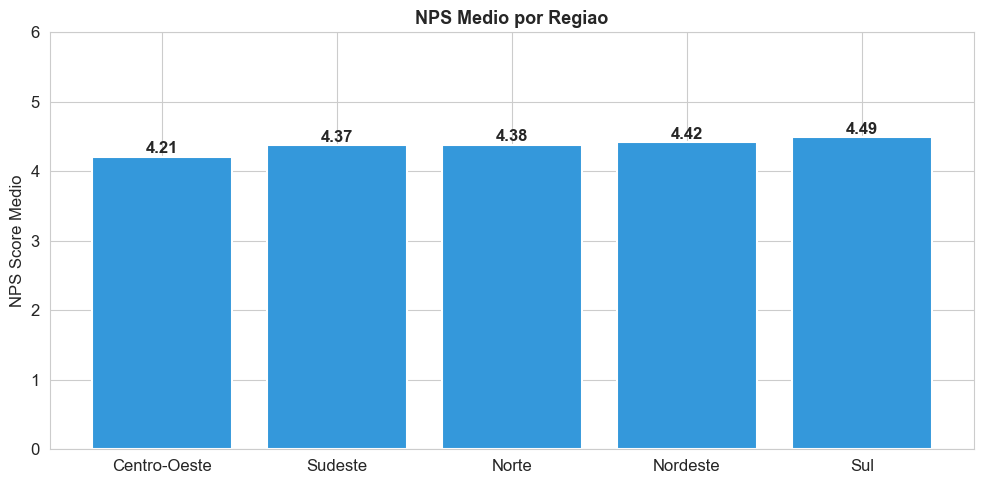

In [10]:
# Fig 5 - NPS por Região
region_nps = df.groupby('customer_region')['nps_score'].mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(region_nps.index, region_nps.values, color='#3498DB', edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, region_nps.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontweight='bold')
ax.set_title('NPS Medio por Regiao', fontsize=13, fontweight='bold')
ax.set_ylabel('NPS Score Medio')
ax.set_ylim(0, 6)
plt.tight_layout()
plt.show()

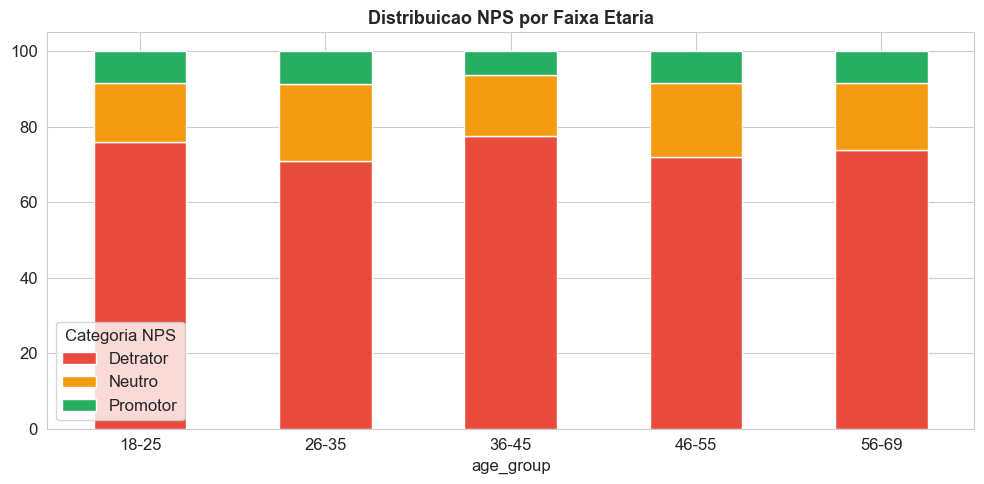

In [11]:
# Fig 6 - NPS por Faixa Etária
df['age_group'] = pd.cut(df['customer_age'],
                          bins=[17, 25, 35, 45, 55, 70],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-69'])
age_nps = df.groupby(['age_group', 'nps_category'], observed=True).size().unstack(fill_value=0)
age_nps_pct = age_nps.div(age_nps.sum(axis=1), axis=0) * 100
age_nps_pct.plot(
    kind='bar', stacked=True,
    color=[PALETTE['Detrator'], PALETTE['Neutro'], PALETTE['Promotor']],
    figsize=(10, 5), edgecolor='white'
)
plt.title('Distribuicao NPS por Faixa Etaria', fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Categoria NPS')
plt.tight_layout()
plt.show()

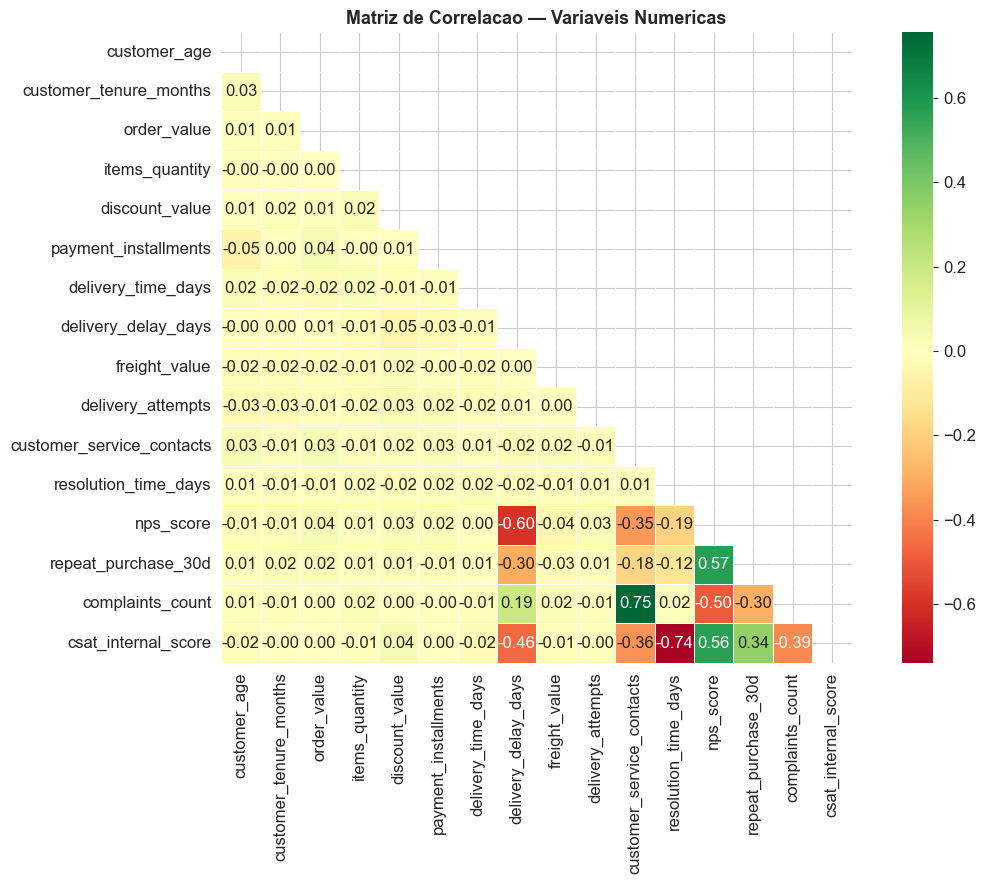

In [12]:
# Fig 7 - Heatmap de Correlações
numeric_cols = df.select_dtypes(include='number').drop(columns=['customer_id', 'order_id'])
corr_matrix = numeric_cols.corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlacao — Variaveis Numericas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Síntese da EDA — Explicação para o Gerente de Operações

### O que mais gera detratores:
1. **Atraso na entrega** é o vilão #1. Com 3+ dias de atraso, 93% dos clientes tornam-se detratores.
2. **Volume de reclamações**: detratores têm média de 4,6 reclamações vs 2,4 dos promotores.
3. **Múltiplos contatos com o SAC**: problema não resolvido no primeiro contato = frustração.

### O que diferencia clientes satisfeitos:
- Entrega dentro do prazo ou com atraso mínimo
- Recompra em 30 dias (ciclo virtuoso de satisfação)

### Variação por Região:
- **Centro-Oeste**: menor NPS médio (4,21) — desafios logísticos
- **Sul**: melhor NPS (4,49)

> *"Se quisermos reduzir detratores, a prioridade #1 é atacar os atrasos de entrega.
> Qualquer pedido com mais de 2 dias de atraso deve acionar um alerta imediato."*


---
# PARTE 4 — Modelagem Preditiva
---

## 4.1 Estratégia: Classificação Binária

**Por que classificação e não regressão?**
Prever o score exato não gera ação direta. Saber que um cliente tem **80% de probabilidade
de ser detrator** permite decisões imediatas: acionar SAC, enviar voucher, priorizar pedido.

**Variável target:**
```python
is_detrator = 1  # nps_score <= 6
is_detrator = 0  # nps_score > 6
```

**Features excluídas por data leakage:**
- `csat_internal_score` — coletada simultaneamente ao NPS
- `repeat_purchase_30d` — consequência do NPS, não causa


In [13]:
# Preparação dos dados
df_model = df.copy()
df_model['is_detrator'] = (df_model['nps_score'] <= 6).astype(int)

le = LabelEncoder()
df_model['region_enc'] = le.fit_transform(df_model['customer_region'])

FEATURES = [
    'customer_age', 'customer_tenure_months',
    'order_value', 'items_quantity', 'discount_value',
    'payment_installments', 'delivery_time_days',
    'delivery_delay_days', 'freight_value', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'region_enc'
]

X = df_model[FEATURES]
y = df_model['is_detrator']

print(f'Features: {len(FEATURES)}')
print(f'Instancias: {len(X)}')
print(f'\nDistribuicao da target:')
print(y.value_counts().rename({0: 'Nao-Detrator', 1: 'Detrator'}))
print(f'\nDesbalanceamento: {y.mean()*100:.1f}% de detratores')

Features: 14
Instancias: 2500

Distribuicao da target:
is_detrator
Detrator        1851
Nao-Detrator     649
Name: count, dtype: int64

Desbalanceamento: 74.0% de detratores


In [14]:
# Separação treino/teste — estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribuicao treino: {y_train.mean()*100:.1f}% detratores')
print(f'Distribuicao teste:  {y_test.mean()*100:.1f}% detratores')

Treino: 2000 amostras (80%)
Teste:  500 amostras (20%)

Distribuicao treino: 74.1% detratores
Distribuicao teste:  74.0% detratores


In [15]:
# Treinamento — Random Forest
# Justificativa:
#   - Robusto a outliers, sem necessidade de normalização
#   - Feature importance interpretável para o negócio
#   - class_weight='balanced' trata o desbalanceamento 74%/26%
#   - Retorna probabilidade (0-100%) para thresholds de ação

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
auc = float(roc_auc_score(y_test, y_prob))
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

print('=' * 50)
print('RESULTADOS — Random Forest Classifier')
print('=' * 50)
print(f'AUC-ROC (teste):     {auc:.4f}')
print(f'AUC-ROC (CV 5-fold): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Nao-Detrator', 'Detrator']))

RESULTADOS — Random Forest Classifier
AUC-ROC (teste):     0.8651
AUC-ROC (CV 5-fold): 0.8684 +/- 0.0196

              precision    recall  f1-score   support

Nao-Detrator       0.73      0.53      0.62       130
    Detrator       0.85      0.93      0.89       370

    accuracy                           0.83       500
   macro avg       0.79      0.73      0.75       500
weighted avg       0.82      0.83      0.82       500



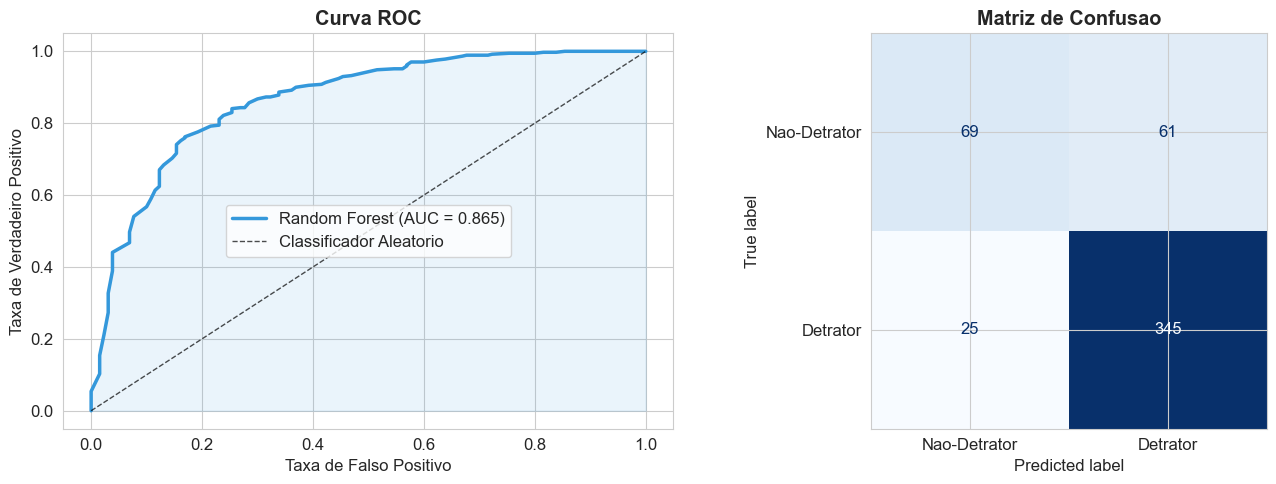

In [16]:
# Fig 8 - Curva ROC + Matriz de Confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#3498DB', linewidth=2.5,
             label=f'Random Forest (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7, label='Classificador Aleatorio')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3498DB')
axes[0].set_xlabel('Taxa de Falso Positivo')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Nao-Detrator', 'Detrator'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusao', fontweight='bold')

plt.tight_layout()
plt.show()

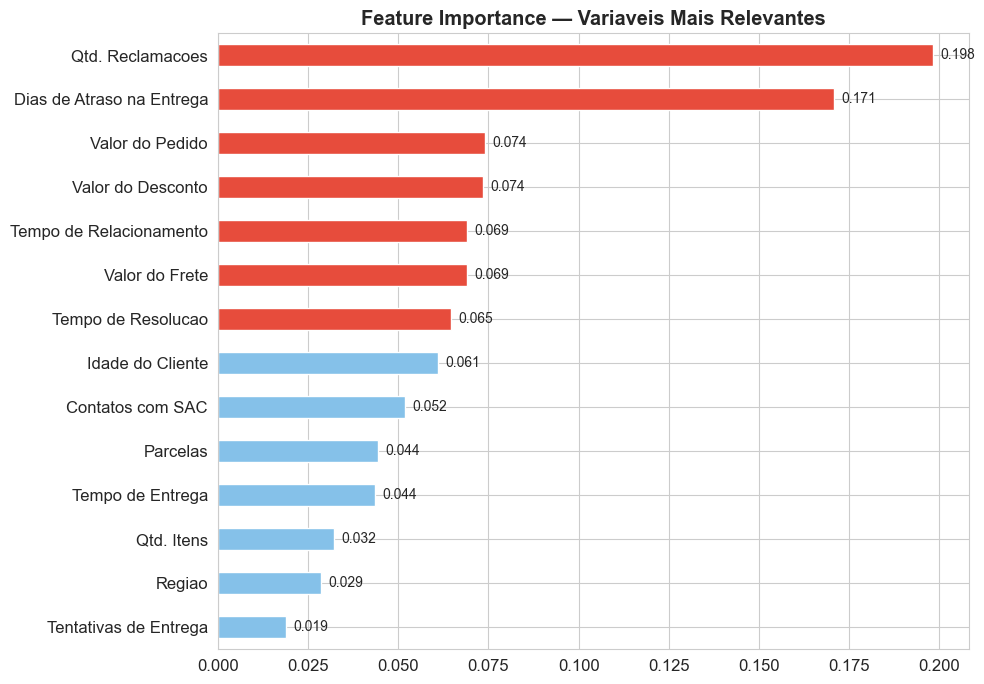


Top 3 variaveis mais importantes:
  Qtd. Reclamacoes: 0.1982
  Dias de Atraso na Entrega: 0.1707
  Valor do Pedido: 0.0740


In [17]:
# Fig 9 - Feature Importance
labels_map = {
    'complaints_count': 'Qtd. Reclamacoes',
    'delivery_delay_days': 'Dias de Atraso na Entrega',
    'order_value': 'Valor do Pedido',
    'discount_value': 'Valor do Desconto',
    'freight_value': 'Valor do Frete',
    'customer_tenure_months': 'Tempo de Relacionamento',
    'customer_age': 'Idade do Cliente',
    'resolution_time_days': 'Tempo de Resolucao',
    'customer_service_contacts': 'Contatos com SAC',
    'delivery_time_days': 'Tempo de Entrega',
    'payment_installments': 'Parcelas',
    'items_quantity': 'Qtd. Itens',
    'region_enc': 'Regiao',
    'delivery_attempts': 'Tentativas de Entrega'
}
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.index = [labels_map.get(f, f) for f in fi.index]

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = ['#E74C3C' if v > fi.median() else '#85C1E9' for v in fi.values]
fi.plot(kind='barh', color=colors_fi, edgecolor='white', ax=ax)
ax.set_title('Feature Importance — Variaveis Mais Relevantes', fontweight='bold')
for i, v in enumerate(fi.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print('\nTop 3 variaveis mais importantes:')
for feat, imp in fi.tail(3)[::-1].items():
    print(f'  {feat}: {imp:.4f}')

In [18]:
# Simulação: scoring de novos clientes
novos_clientes = pd.DataFrame({
    'customer_age':             [35,  52,  28],
    'customer_tenure_months':   [24,   6,   1],
    'order_value':              [350, 200, 600],
    'items_quantity':           [3,    2,   5],
    'discount_value':           [20,   0,  50],
    'payment_installments':     [3,    1,  10],
    'delivery_time_days':       [3,    7,   2],
    'delivery_delay_days':      [0,    5,   1],
    'freight_value':            [15,  45,  25],
    'delivery_attempts':        [1,    3,   2],
    'customer_service_contacts':[0,    4,   1],
    'resolution_time_days':     [0,   10,   3],
    'complaints_count':         [1,    7,   3],
    'region_enc':               [0,    2,   4],
})
probs = rf.predict_proba(novos_clientes)[:, 1]
preds = rf.predict(novos_clientes)

resultado = novos_clientes[['delivery_delay_days', 'complaints_count',
                             'customer_service_contacts']].copy()
resultado['P(Detrator)'] = [f'{p*100:.1f}%' for p in probs]
resultado['Previsao']    = ['DETRATOR' if p == 1 else 'Nao-Detrator' for p in preds]
resultado['Acao']        = [
    'SAC Proativo + Voucher' if p > 0.8
    else 'E-mail de verificacao' if p > 0.6
    else 'Fluxo padrao'
    for p in probs
]
print('Scoring de Novos Clientes:')
print(resultado.to_string(index=False))

Scoring de Novos Clientes:
 delivery_delay_days  complaints_count  customer_service_contacts P(Detrator)     Previsao                   Acao
                   0                 1                          0        7.0% Nao-Detrator           Fluxo padrao
                   5                 7                          4       90.0%     DETRATOR SAC Proativo + Voucher
                   1                 3                          1       64.0%     DETRATOR  E-mail de verificacao


---
# Conclusões Finais
---

## Resumo Executivo

Este projeto demonstrou que é possível **prever com 83% de acurácia e AUC de 0,865**
se um cliente será um detrator, utilizando apenas dados operacionais disponíveis antes
da coleta do NPS.

## Os 3 Principais Insights de Negócio

1. **Atraso na entrega é o gatilho principal**: A partir de 3 dias de atraso, 93% dos
   clientes tornam-se detratores. SLA de entrega é o maior alavancador de NPS.

2. **Volume de reclamações revela falhas sistêmicas**: Correlação de -0,50 indica
   que processos com alta taxa de reclamação precisam ser revisados urgentemente.

3. **O modelo permite ação proativa**: Com scoring em tempo real, a empresa pode
   intervir **antes** que o cliente registre NPS negativo.

## Próximos Passos

- **Feature Engineering**: criar variáveis derivadas (ratio atraso/tempo_estimado)
- **Balanceamento**: aplicar SMOTE para melhorar recall da classe minoritária
- **XGBoost / LightGBM**: testar modelos de gradient boosting
- **Deploy**: implementar via API REST para integração em tempo real
- **Monitoramento**: acompanhar drift do modelo com métricas de performance
